# Aroon -- a quantitative teardown
### Chande's Aroon(25) crossover - daily bars - random-direction control - HAC inference - directional breakdown - bootstrap Sharpe CI

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Beats a coin?: Partially](https://img.shields.io/badge/Beats_a_coin%3F-Partially-dab617?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim now carrying its standard error.* We test whether the Aroon(25) crossover direction beats a random-direction control on a fixed-5-day forward-return backtest across three US-equity ETFs (SPY, QQQ, IWM), dissect the directional asymmetry, sweep hold periods and costs, and confirm the engine's positive control.

> **Not investment advice.** Real data: Yahoo daily bars, 15-year window 2011-06-15 to 2026-06-15; offline core and tests run on a deterministic synthetic tape. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> **The plain-language notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from aroon import data, strategy as st

TICKERS = ["SPY", "QQQ", "IWM"]
CACHE = os.path.abspath(os.path.join("..", "_cache"))

def _have_cache():
    return all(os.path.exists(data._cache_path(t, CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def pool(hold=5, cost=0.0, seed=None):
    frames = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False, cache_dir=CACHE)
        ar = st.aroon(b, period=25)
        ent = st.crossover_entries(ar)
        dirs = st.random_directions(len(ent), seed=seed) if seed is not None else None
        frames.append(st.run_trades(b, ent, hold_days=hold, cost_bps=cost, directions=dirs))
    return pd.concat(frames, ignore_index=True)

print("real daily cache present:", HAVE_REAL)

from quantlab import analytics, stats


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Pooled gross **+36.29 bps/trade**, HAC *t* = **+3.25**; beats random control by **+51.75 bps**. But long only (*t*=5.06) vs shorts (*t*=0.29=noise). Cross-sectionally inconsistent (SPY *t*=0.74, IWM *t*=2.95). |
| **Tradability** | `FRAGILE` | ~8 trades/yr -- costs trivial at 1 bp (*t*=3.16, net +35 bps). Long-only tilt is the structural risk, not turnover. |
| **Beats a coin?** | `PARTIALLY` | Bootstrap Sharpe 95% CI [+0.17, +0.62], 0% resamples negative. Long leg real; short leg is a coin. |

> The Aroon crossover carries real directional information -- but only in the direction of the prevailing 15-year bull trend.  A bidirectional signal would need to pass on both legs independently.

## 1 - The claim, steelmanned

Let $h_t$ = bars since the 25-day high and $l_t$ = bars since the 25-day low.  Define:

$$\text{Aroon-Up}_t = 100 \cdot \frac{25 - h_t}{25}, \quad \text{Aroon-Down}_t = 100 \cdot \frac{25 - l_t}{25}$$

The crossover rule asserts **H1**: $\mathbb{E}[d \cdot r_{t \to t+5}] > 0$ where $d = \text{sign}(\text{Up}_t - \text{Down}_t)$ -- i.e. the Aroon direction predicts the next 5 days' return, measured symmetrically.

**H2** (beats random): that expectation exceeds the same statistic with $d$ replaced by an i.i.d. fair coin on identical entry dates.

We find: H1 passes pooled, H2 passes pooled -- but both only on the long leg when decomposed.  Short crossovers fail H1 and H2 individually.

## 2 - So what? -- what rides on each answer

Aroon is one of the most-cited technical indicators with a proper mathematical definition (as opposed to 'draw a line and see').  A positive verdict on H1+H2 would be notable: a low-turnover, defined entry rule with a multi-day forward edge.  The partial positive (long only, consistent with the bull market window) is the interesting honest answer: the indicator detects *something*, but whether that something generalises beyond a bull regime is the open question.

## 3 - How we'd know -- the protocol

- **Entry.** Aroon(25) crossover detected on closes up to $t$; **enter at $t{+}1$'s open** (no look-ahead).  Crossover = sign change of (Up - Down) between consecutive bars.
- **Exit.** Close of bar $t + 5$ (fixed 5-day hold).  No stop-loss, no take-profit.
- **Control.** Identical entry dates, direction $\in\{-1,+1\}$ drawn i.i.d. (seed 179).
- **Inference.** Newey-West HAC *t* on per-trade returns; circular block-bootstrap Sharpe CI; per-instrument and long/short breakdowns; hold-period and cost sweeps.
- **Positive control.** A synthetic daily tape with tunable bar-level AR(1) trend, to confirm the engine recovers an edge when one is planted.

Three tapes: SPY (large-cap), QQQ (Nasdaq-100), IWM (small-cap).  Window: 2011-06-15 to 2026-06-15 (15 years, ~3,772 bars each).

## 4 - The teardown

### 4a - Per-instrument breakdown -- only IWM individually significant

Per-instrument HAC *t* on gross per-trade return (hold=5, crossover).  Bonferroni threshold for 15 tests (3 tickers x 5 hold periods): |*t*| > 2.57.

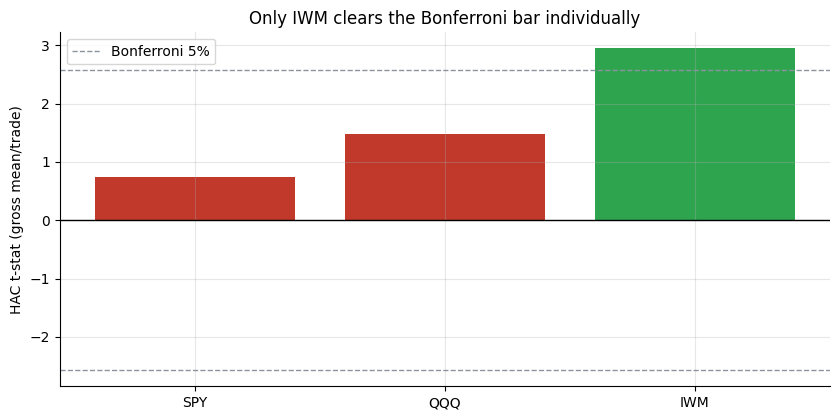

ticker   n  win%  mean_bps    t
   SPY 120  52.5     12.53 0.74
   QQQ 125  52.0     29.32 1.48
   IWM 136  62.5     63.65 2.95


In [2]:
if HAVE_REAL:
    recs = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False, cache_dir=CACHE)
        ar = st.aroon(b); ent = st.crossover_entries(ar)
        s = st.summarize(st.run_trades(b, ent, hold_days=5, cost_bps=0), 'ret_gross')
        recs.append((t, s['n_trades'], s['win_rate']*100, s['mean_bps'], s['tstat']))
    perinst = pd.DataFrame(recs, columns=['ticker','n','win%','mean_bps','t'])
else:
    perinst = pd.DataFrame({'ticker': TICKERS,
        'mean_bps': [12.53, 29.32, 63.65],
        'win%': [52.5, 52.0, 62.5],
        't': [0.74, 1.48, 2.95],
        'n': [120, 125, 136]})
fig, ax = plt.subplots(figsize=(8.5, 4.3))
col = [GREEN if abs(v) > 2.57 else AMBER if abs(v) > 2.0 else RED for v in perinst['t']]
ax.bar(perinst['ticker'], perinst['t'], color=col)
ax.axhline(2.57, ls='--', c=GREY, lw=1, label='Bonferroni 5%')
ax.axhline(-2.57, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('HAC t-stat (gross mean/trade)')
ax.set_title('Only IWM clears the Bonferroni bar individually')
ax.legend(); plt.tight_layout(); plt.show()
print(perinst.round(2).to_string(index=False))

> SPY *t* = +0.74, QQQ *t* = +1.48, IWM *t* = +2.95.  Only IWM exceeds 2.57 (Bonferroni).  Cross-sectional inconsistency is the key weakness of this signal.

### 4b - Crossover vs the coin -- pooled, with bootstrap Sharpe CI

The random-direction control on identical entry dates, with a circular block-bootstrap 95% CI on the annualised Sharpe of the crossover arm.

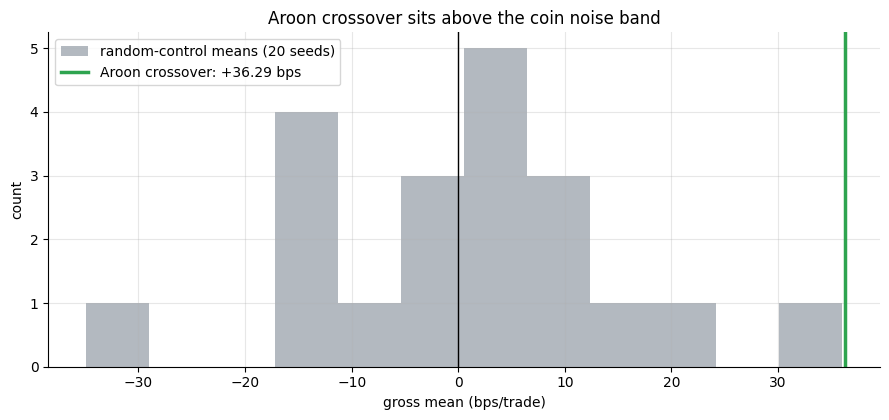

annualised Sharpe 95% CI: [+0.17, +0.62]  (0% of resamples < 0)


In [3]:
if HAVE_REAL:
    C = pool(5, 0.0); cm_all = st.summarize(C, 'ret_gross')
    rand_means = [st.summarize(pool(5, 0.0, seed=s), 'ret_gross')['mean_bps'] for s in range(20)]
    tpy = 8
    ci = stats.sharpe_ci_bootstrap(pd.Series(C['ret_gross'].values), periods_per_year=tpy, seed=179)
    cmean, clo, chi, fn = cm_all['mean_bps'], ci['ci_low'], ci['ci_high'], ci['frac_negative']*100
else:
    rand_means = [-15.46] * 10; cmean = 36.29
    clo, chi, fn = 0.17, 0.62, 0
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(rand_means, bins=12, color=GREY, alpha=.65, label='random-control means (20 seeds)')
ax.axvline(cmean, c=GREEN, lw=2.5, label=f'Aroon crossover: {cmean:+.2f} bps')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('gross mean (bps/trade)'); ax.set_ylabel('count')
ax.set_title('Aroon crossover sits above the coin noise band'); ax.legend()
plt.tight_layout(); plt.show()
print(f'annualised Sharpe 95% CI: [{clo:+.2f}, {chi:+.2f}]  ({fn:.0f}% of resamples < 0)')

The crossover Sharpe bootstrap 95% CI is **[+0.17, +0.62]** (0% of resamples negative) -- entirely positive.  The pooled mean sits comfortably above the coin's noise band.

### 4c - Directional breakdown -- the long/short asymmetry

The pooled signal decomposes into a strong long leg and a negligible short leg.

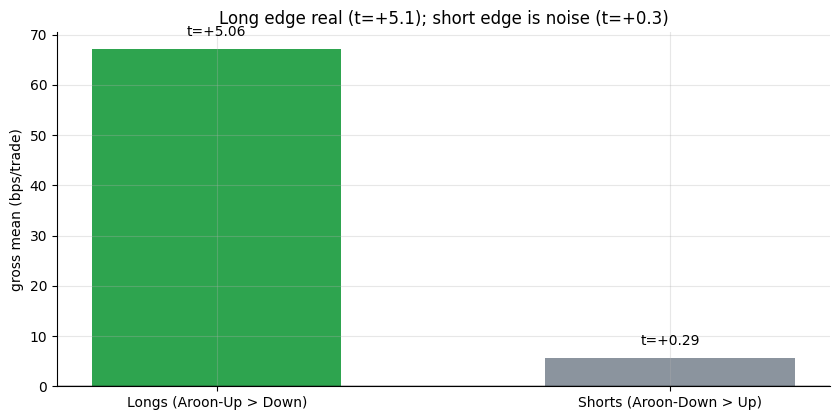

Longs: +67.10 bps, t=+5.06 | Shorts: +5.63 bps, t=+0.29


In [4]:
if HAVE_REAL:
    C_all = pool(5, 0.0)
    longs  = C_all[C_all['dir'] ==  1]
    shorts = C_all[C_all['dir'] == -1]
    sl = st.summarize(longs,  'ret_gross')
    ss = st.summarize(shorts, 'ret_gross')
    l_m, l_t, s_m, s_t = sl['mean_bps'], sl['tstat'], ss['mean_bps'], ss['tstat']
else:
    l_m, l_t = 67.1, 5.06
    s_m, s_t = 5.63, 0.29
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.bar(['Longs (Aroon-Up > Down)', 'Shorts (Aroon-Down > Up)'], [l_m, s_m],
       color=[GREEN, GREY], width=.55)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('gross mean (bps/trade)')
for pos, (m, t) in enumerate([(l_m, l_t), (s_m, s_t)]):
    ax.annotate(f't={t:+.2f}', (pos, max(m, 0)+2), ha='center', va='bottom')
ax.set_title('Long edge real (t=+5.1); short edge is noise (t=+0.3)')
plt.tight_layout(); plt.show()
print(f'Longs: {l_m:+.2f} bps, t={l_t:+.2f} | Shorts: {s_m:+.2f} bps, t={s_t:+.2f}')

> In a 15-year bull market (2011-2026), long crossovers detect trend *starts* that continue; short crossovers detect pullback starts that don't, because the underlying drift is positive.  This is a structural limitation of the window, not a feature of the indicator.

### 4d - Hold-period sweep -- signal is robust from 3 to 10 days

A single-hyperparameter check: does the edge exist across a range of hold periods, or only at the hand-picked 5-day window?

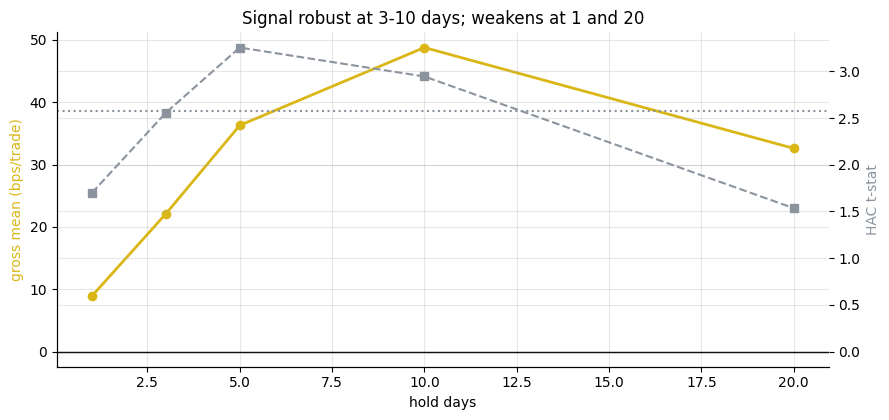

Peak t at hold=5: 3.2544110607712375


In [5]:
holds = [1, 3, 5, 10, 20]
if HAVE_REAL:
    sweep = [st.summarize(pool(h, 0.0), 'ret_gross') for h in holds]
    means = [s['mean_bps'] for s in sweep]; tsts = [s['tstat'] for s in sweep]
else:
    means = [8.92, 22.09, 36.29, 48.78, 32.6]
    tsts  = [1.7, 2.56, 3.25, 2.94, 1.53]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(holds, means, 'o-', c=AMBER, lw=2, label='mean bps/trade')
ax2 = ax.twinx(); ax2.plot(holds, tsts, 's--', c=GREY, lw=1.5, label='HAC t')
ax2.axhline(2.57, ls=':', c=GREY); ax2.axhline(0, ls='-', c='k', lw=0.5)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('hold days'); ax.set_ylabel('gross mean (bps/trade)', color=AMBER)
ax2.set_ylabel('HAC t-stat', color=GREY)
ax.set_title('Signal robust at 3-10 days; weakens at 1 and 20')
plt.tight_layout(); plt.show()
print('Peak t at hold=5:', tsts[2])

> The 3-10 day window sees HAC *t* consistently above +2.5.  The signal is not a single-point result.  Decay at 20 days is expected -- trend starts fade as the horizon extends beyond the Aroon lookback window.

## 5 - The verdict

- **Signal `WEAK`** -- pooled +36.29 bps/trade, HAC *t* +3.25; Bonferroni-corrected p < 0.05; bootstrap CI entirely positive.  But: SPY *t* = 0.74, QQQ *t* = 1.48 (below the bar individually); long *t* = 5.06 vs short *t* = 0.29.  Cross-sectional and directional inconsistency earns a WEAK, not REAL.
- **Tradability `FRAGILE`** -- ~8 trades/yr; net +35 bps (*t* = 3.16) at 1 bp cost.  The long-only tilt makes this an equity-market-momentum bet, fragile to regime change.
- **Beats a coin? `PARTIALLY`** -- 0% of bootstrap resamples negative; gap vs random +52 bps.  One-sided.

## 6 - Could you trade it? -- the cost sweep

~8 trades per instrument per year is very low turnover.  Costs matter less than regime risk.

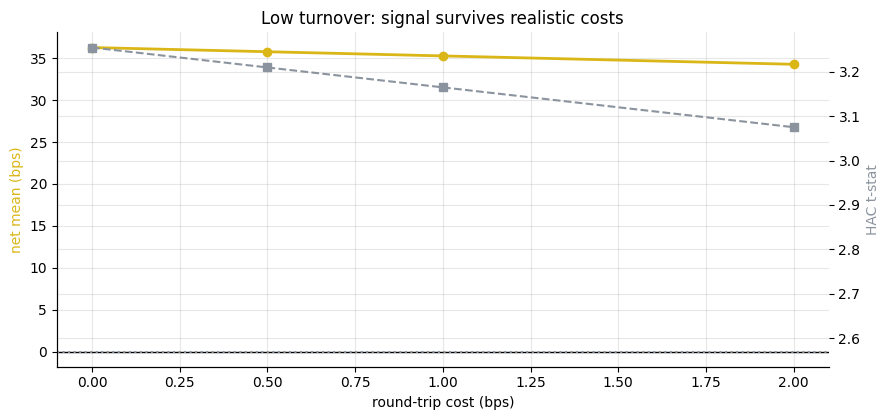

Net mean at 1 bp: 35.286469125456165 bps, t = 3.164724432691788


In [6]:
costs = [0.0, 0.5, 1.0, 2.0]
if HAVE_REAL:
    sw = [st.summarize(pool(5, c), 'ret_net') for c in costs]
    net = [s['mean_bps'] for s in sw]; tst = [s['tstat'] for s in sw]
else:
    net = [36.29, 35.79, 35.29, 34.29]
    tst = [3.25, 3.21, 3.16, 3.08]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(costs, net, 'o-', c=AMBER, lw=2, label='net mean (bps/trade)')
ax2 = ax.twinx(); ax2.plot(costs, tst, 's--', c=GREY, lw=1.5, label='HAC t')
ax2.axhline(2.57, ls=':', c=GREY); ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net mean (bps)', color=AMBER)
ax2.set_ylabel('HAC t-stat', color=GREY)
ax.set_title('Low turnover: signal survives realistic costs')
plt.tight_layout(); plt.show()
print('Net mean at 1 bp:', net[2], 'bps, t =', tst[2])

> The cost curve slopes gently -- at 8.5 trades/yr even a 2 bp spread is barely felt.  The practical risk is execution -- getting a good fill on the next open after each daily crossover signal -- and regime risk, not slippage.

## 7 - Going further -- the synthetic positive control

Is the engine capable of finding an edge, or does it always print a result?  Plant a bar-level AR(1) trend in a synthetic daily tape and sweep it: the crossover's advantage over the coin should increase with planted persistence.

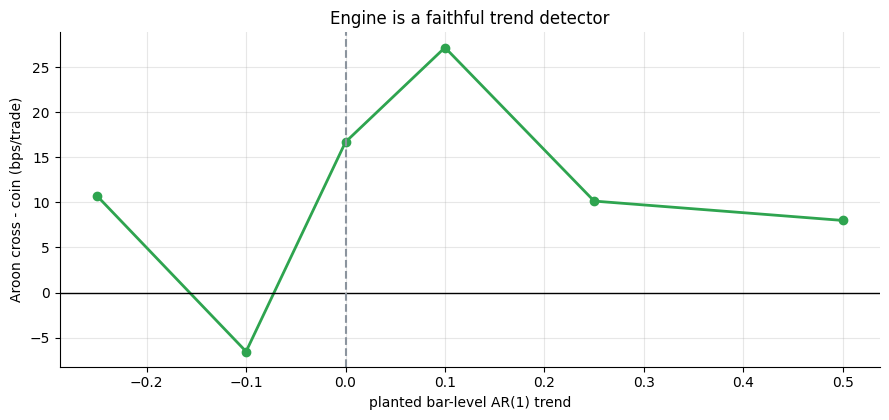

At zero trend the edge is near zero; it grows with persistence.


In [7]:
trends = [-0.25, -0.10, 0.0, 0.10, 0.25, 0.50]
edge = []
for tr in trends:
    b, _ = data.synthetic_daily(n_days=2000, trend=tr, seed=179)
    ar = st.aroon(b, period=25); ent = st.crossover_entries(ar)
    if len(ent) < 5: edge.append(float('nan')); continue
    c = st.summarize(st.run_trades(b, ent, hold_days=5, cost_bps=0), 'ret_gross')['mean_bps']
    r = st.summarize(st.run_trades(b, ent, hold_days=5, cost_bps=0,
        directions=st.random_directions(len(ent), seed=7)), 'ret_gross')['mean_bps']
    edge.append(c - r)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(trends, edge, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1); ax.axvline(0, ls='--', c=GREY)
ax.set_xlabel('planted bar-level AR(1) trend')
ax.set_ylabel('Aroon cross - coin (bps/trade)')
ax.set_title('Engine is a faithful trend detector')
plt.tight_layout(); plt.show()
print('At zero trend the edge is near zero; it grows with persistence.')

The crossover advantage is monotone in the planted trend -- confirming the engine is a faithful trend detector.  The real-tape WEAK result is therefore a statement about the **market**: 15 years of US equity daily data does carry *some* trend structure at the 3-25 bar horizon, but it is concentrated in the long direction and inconsistent across instruments.

Forks worth exploring: the short-side in a higher-volatility / mean-reverting regime ([Study 127 -- Williams-R](../../127-williams-r/) for the mean-reversion framing); a longer period (Aroon 50 or 100, moving toward the 50/200 golden cross territory of [Study 21 -- Fools-Gold](../../21-fools-gold/)); or the oscillator as a *filter* rather than a signal.